## Astro kod

### Parser

In [1]:
# Parser
import numpy as np
import scipy as sci
import astropy as aspy
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits


from os import listdir
from os.path import isfile, join
import time
from datetime import datetime


# Returnerar lista av (band (int), tidpunkt (datetime), bild_data (np.ndarray av ra, dec, intensitet))
def parseFits(fits_dir):
    # Hämta lista av fits filer från mapp
    fits_files = [fits_file for fits_file in listdir(fits_dir) if isfile(join(fits_dir, fits_file))]

    observations = list()
    date_format = "%Y-%m-%dT%H:%M:%S.%f"

    # Gå igenom varje fits fil
    for fits_file in fits_files:
        # Öppna fitsfil
        # HDUList (Header Data Unit)
        hdul = fits.open(fits_dir + fits_file)
        # hdul.info() # Printar lite info om fitsfilen

        # Header information
        # Se: http://www.alma.inaf.it/images/ArchiveKeyworkds.pdf
        header = hdul[0].header
        #print(repr(header))

        # Få band
        band = int(fits_file[fits_file.find('B')+1])

        # Få observationsdatum och tid
        date_str = header['DATE-OBS']
        date = datetime.strptime(date_str, date_format)

        # Bilddatan
        intensities = np.squeeze(hdul[0].data)

        width, height = intensities.shape
        x_pixels = np.linspace(0, width, width)
        y_pixels = np.linspace(0, height, height)

        # Right ascension
        ra_ref = header['CRVAL1'] # RA referens i relation till Pixel referensen
        ra_delta = header['CDELT1'] # RA delta för varje pixel
        ra_pixel_ref = header['CRPIX1'] # Pixel positionen där RA referens gäller

        # Declination
        dec_ref = header['CRVAL2']
        dec_delta = header['CDELT2']
        dec_pixel_ref = header['CRPIX2']

        # Konvertera från pixel koordinater till ekvatoriella koordinater
        ras = ra_ref + (x_pixels - ra_pixel_ref) * ra_delta
        decs = dec_ref + (y_pixels - dec_pixel_ref) * dec_delta

        observations.append((band, date, ras, decs, intensities))

    return observations


In [2]:
# Parsea fits data för de tre AGB-stjärnorna
R_Dor = parseFits("data/RDor/")
R_Leo = parseFits("data/aop_mount/home/wouterv/DATA/AGB_Continuum_files/RLeo/")
W_Hya = parseFits("data/aop_mount/home/wouterv/DATA/AGB_Continuum_files/WHya/")

### Centrum metoder

R Dorados Max intensitet 
R Dorados Gaussisk 
Band:  4 Tidpunkt:  2023-10-13 06:30:01.344000


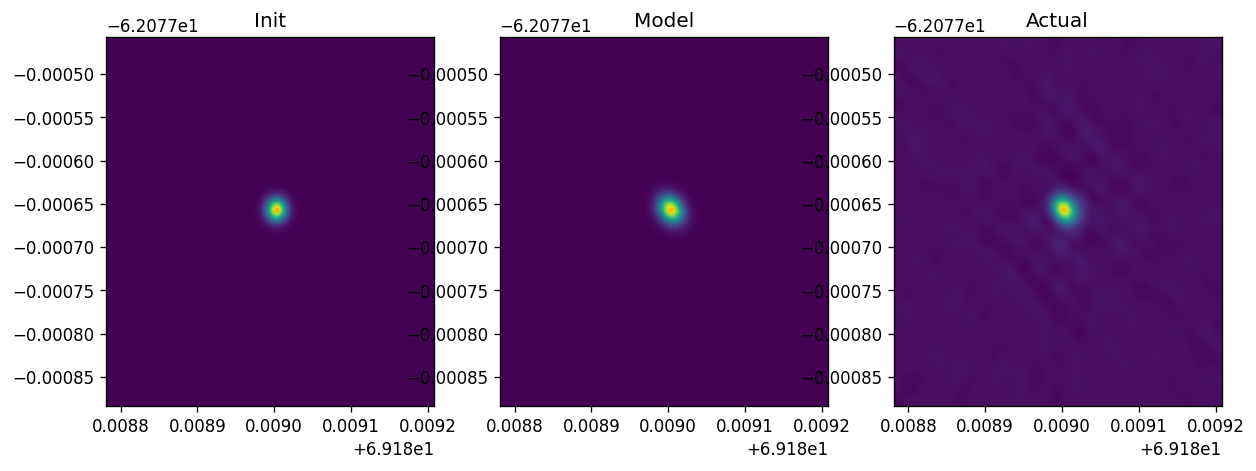

Band:  4 Tidpunkt:  2023-10-01 05:54:11.951998


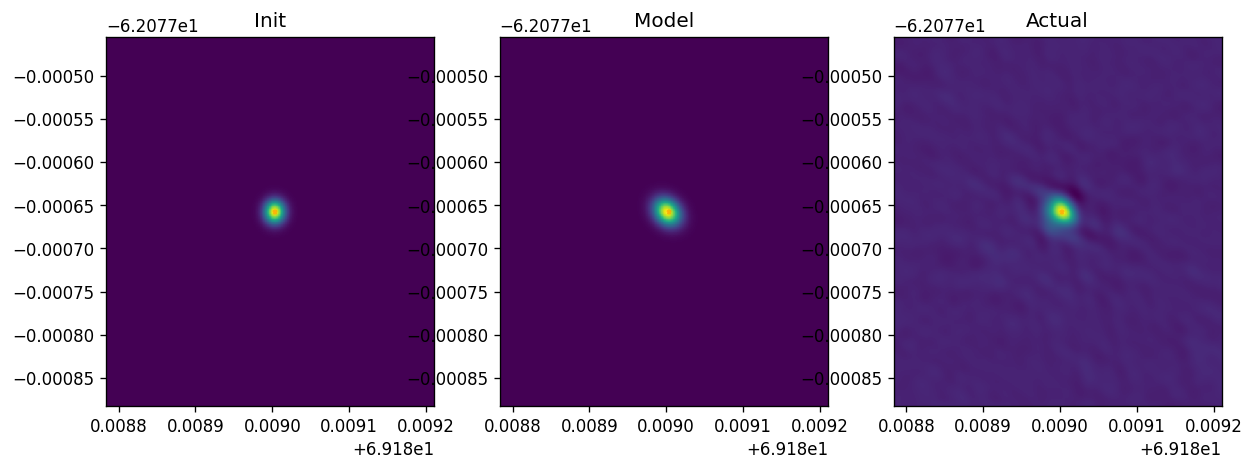

Band:  7 Tidpunkt:  2023-10-06 08:41:13.248000


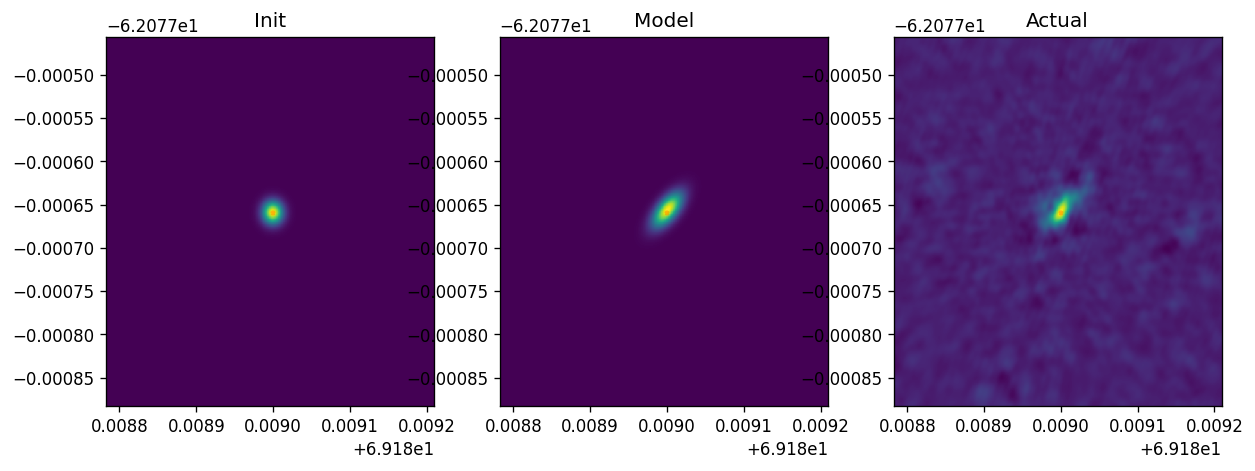

Band:  9 Tidpunkt:  2023-11-04 05:21:07.200000


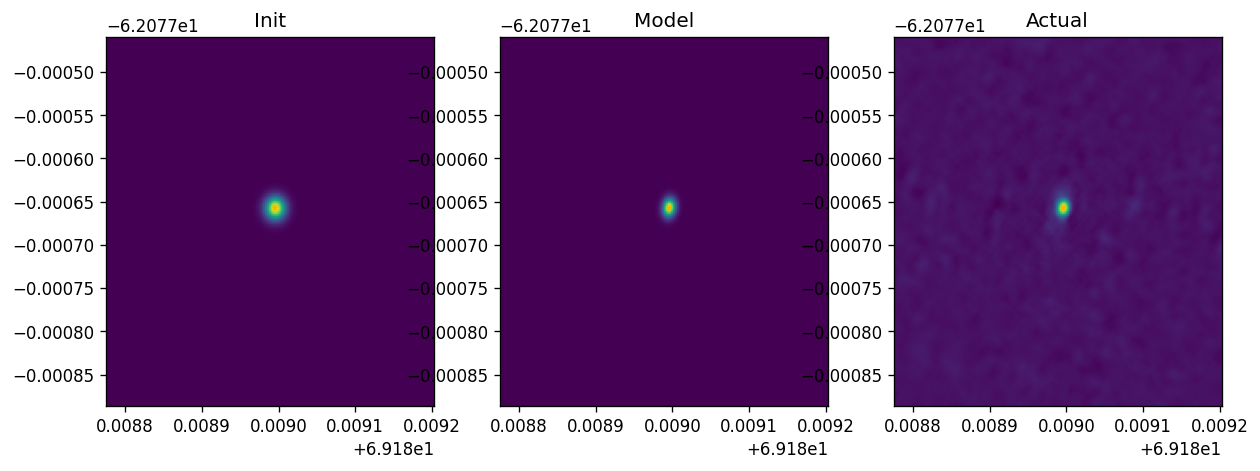

Band:  7 Tidpunkt:  2023-10-09 06:22:48.479999


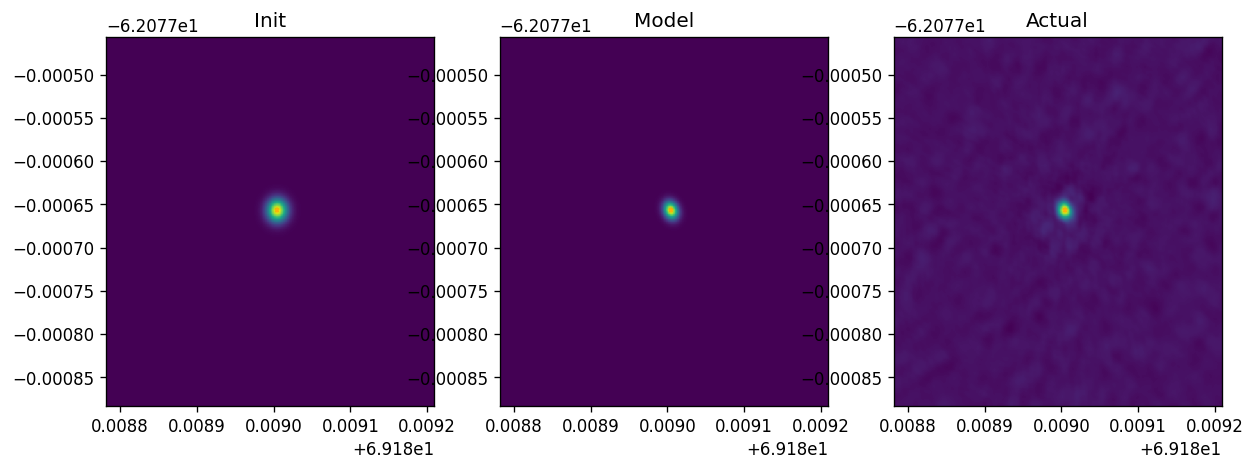

Band:  4 Tidpunkt:  2023-10-04 07:07:52.176001


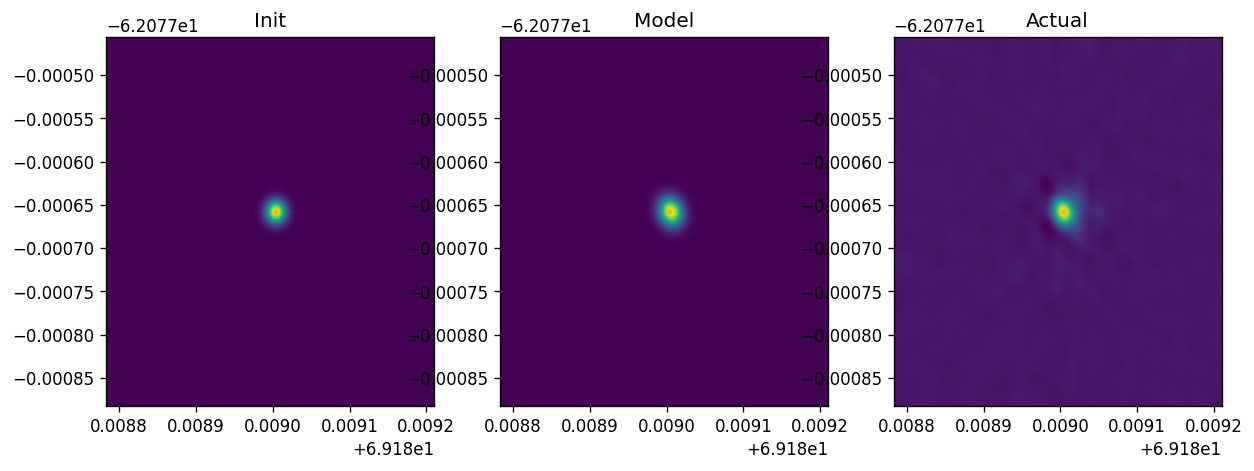

Band:  7 Tidpunkt:  2023-10-04 07:37:15.600000


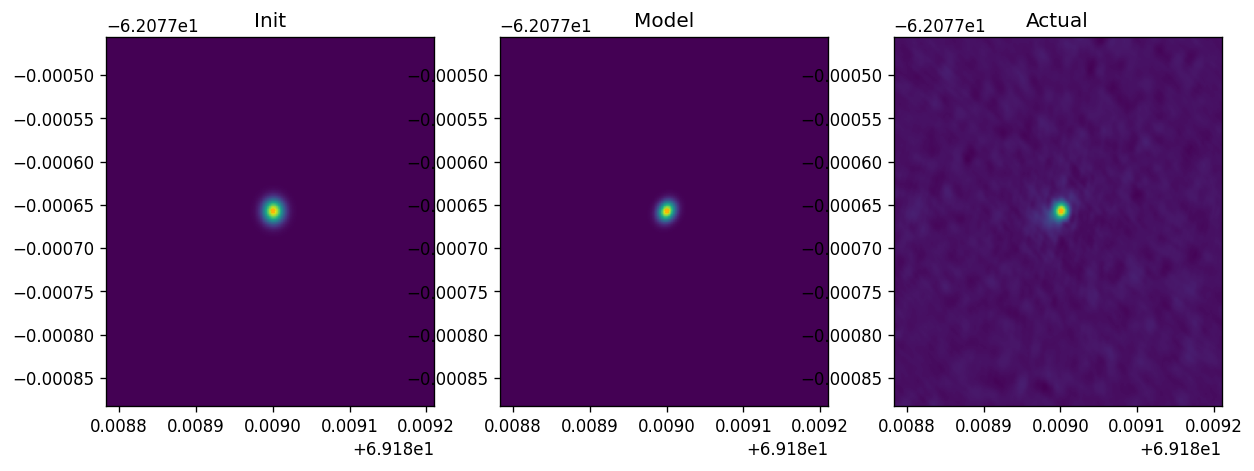

Band:  4 Tidpunkt:  2023-10-06 08:14:26.399999


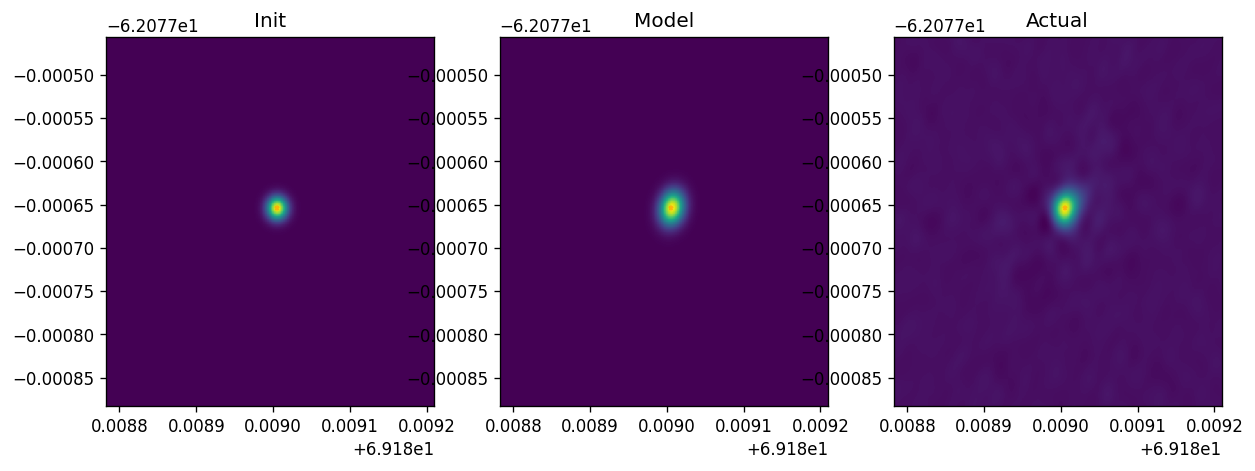

Band:  7 Tidpunkt:  2023-10-12 07:19:20.016000


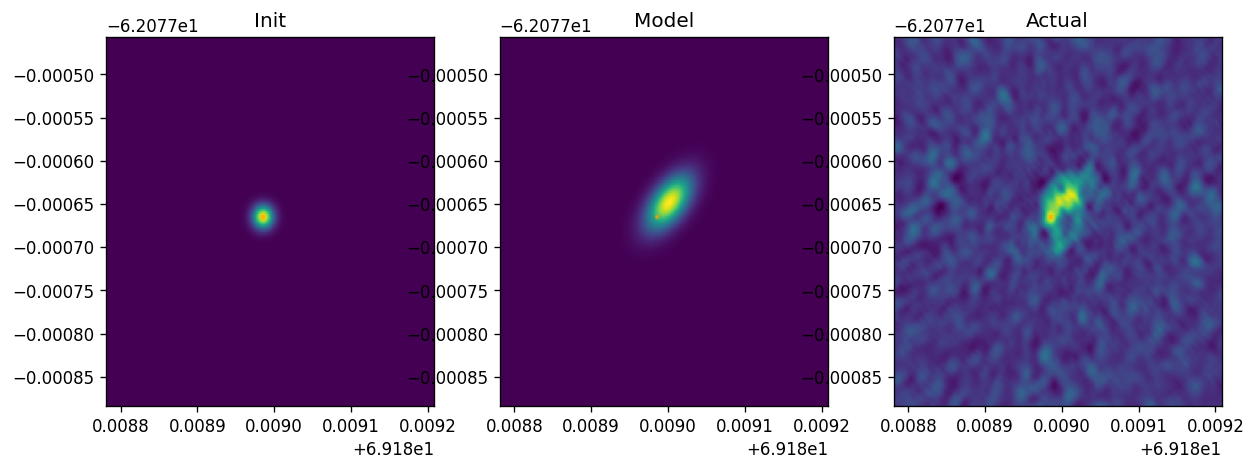

Band:  8 Tidpunkt:  2023-11-03 07:49:49.008000


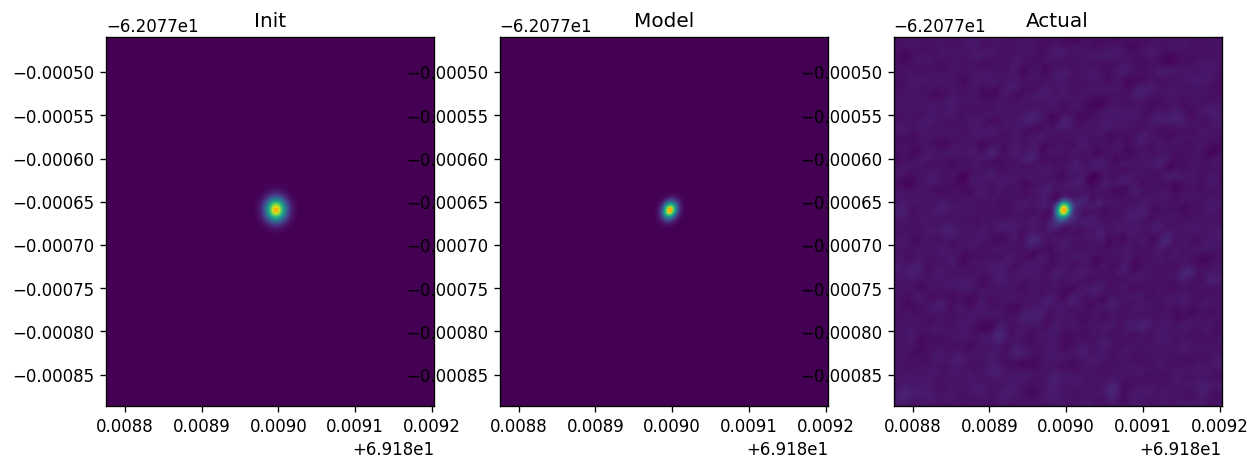

Band:  4 Tidpunkt:  2023-10-09 11:02:37.104000


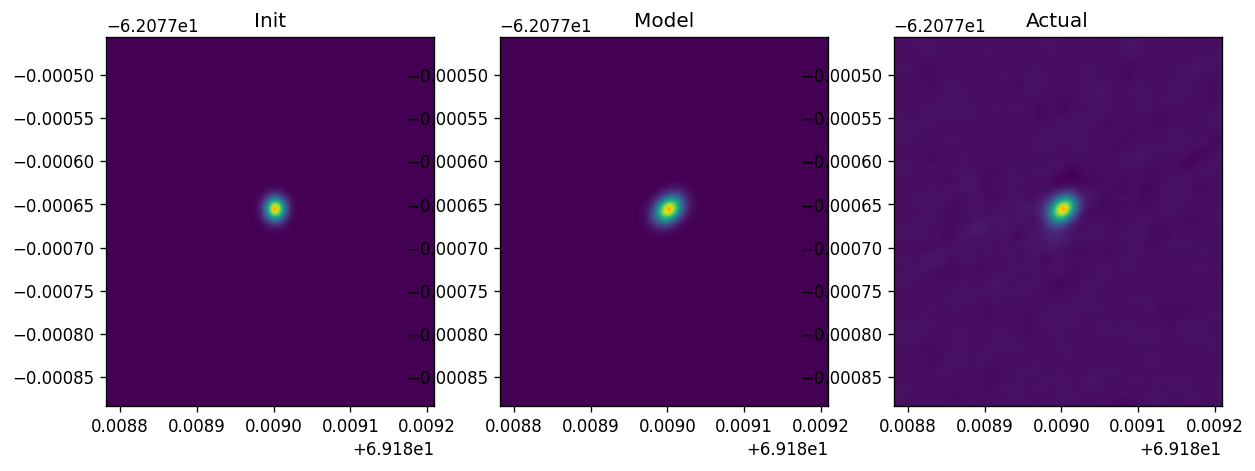

R Leonis Max intensitet 
R Leonis Gaussisk 
W Hydrae Max intensitet 
W Hydrae Gaussisk 
Star plot 


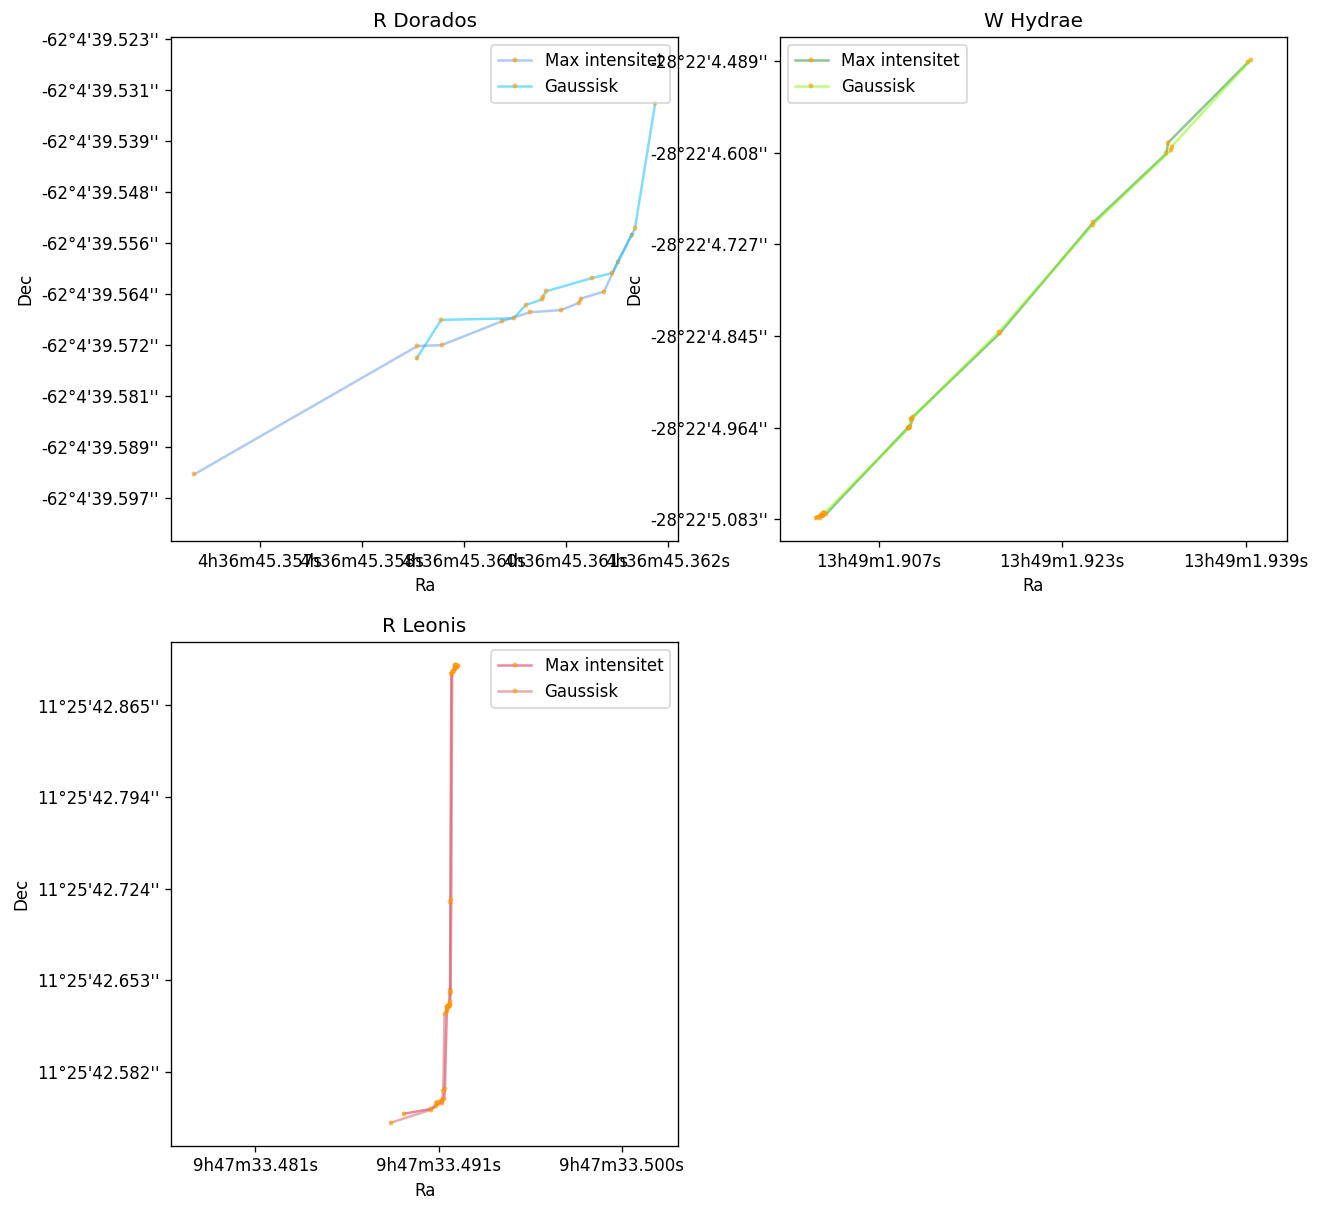

In [ ]:
# Centrum metoder

import matplotlib.ticker as tick

from astropy.modeling import models, fitting

# Hitta centrum med ljusaste punkt:
def maxIntensitet(ras, decs, intensities, debug=False):
    # Hämta index för ljusaste intensitet
    j, i = np.unravel_index(np.argmax(intensities, axis=None), intensities.shape)

    return ras[i], decs[j], intensities[i, j]

# Få centerpunkter med metod och observationer
# Ger tillbaka tidpunkter, ra:s och dec:s
def getCenters(method, observations, debug=False):
    ts = []
    ras = []
    decs = []

    # Gå igenom varje observaton
    for observation in observations:
        ts.append(observation[1])
        if debug:
            print("Band: ", observation[0], "Tidpunkt: ", observation[1])
        ra, dec, intensitet = method(observation[2], observation[3], observation[4], debug=debug)

        ras.append(ra)
        decs.append(dec)

    # Sortera datan enligt observationstid
    data = np.array([ts, ras, decs])
    data = np.sort(data)

    return data


# Formatterar deklinationen till string format
def decFormatter(dec, pos): 
    dec_deg = int(dec)
    dec_arcmin = int(60 * (dec - dec_deg))
    dec_arcsec = 60 * (60 * (dec - dec_deg) - dec_arcmin)

    return f"{dec_deg}°{abs(dec_arcmin)}'{abs(dec_arcsec):.3f}''"

# Formatterar rektascension till string format
def raFormatter(ra, pos): 
    ra /= 15
    ra_hour = int(ra)
    ra_min = int(60 * (ra - ra_hour))
    ra_sec = 60 * (60 * (ra - ra_hour) - ra_min)

    return f"{ra_hour}h{abs(ra_min)}m{abs(ra_sec):.3f}s"

# Hitta centrum med gauss anpassning:
def gaussIntensitet(ras, decs, intensities, debug=False):
    r, d = np.meshgrid(ras, decs)

    # Få ut maximala intensiteten som utgångspunkt för den gaussiansk anpassningen
    ra_max, dec_max, int_max = maxIntensitet(ras, decs, intensities)

    # Standard avvikelse satt till 12 arcsec, rimlig approximation av stjärnans radie
    stddev_factor = 12/(360*60*60)

    # Initala gauss modellen: Startpunkt för anpassningen
    gauss_init = models.Gaussian2D(amplitude=1, x_mean=ra_max, y_mean=dec_max, \
                                   x_stddev=stddev_factor, y_stddev=stddev_factor)
    
    # Anpassningsmetoden som fungerade bäst. TODO: Undersök varför och om det finns bättre anpassare
    gauss_fitter = fitting.DogBoxLSQFitter()

    # Gör gaussisk anpassning med en maximal iteration på 10'000, (lägre gav sämre resultat)
    gauss_model = gauss_fitter(gauss_init, r, d, intensities, maxiter=10000) 

    # För debug så plottas den initiala gauss modellen, den gaussiska anpassningen och ursprungliga stjärnbilden bredvid varandra.
    if debug:
        fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=120)
        fig.suptitle("")
        axs[0].set_title("Init")
        axs[0].pcolormesh(ras, decs, gauss_init(r, d))
        axs[0].plot(ra_max, dec_max, marker='*', markerfacecolor="gold", markeredgecolor="darkorange", alpha=0.5, markersize=3.0)
        axs[1].set_title("Model")
        axs[1].pcolormesh(ras, decs, gauss_model(r, d))
        axs[1].plot(ra_max, dec_max, marker='*', markerfacecolor="gold", markeredgecolor="darkorange", alpha=0.5, markersize=3.0)
        axs[2].set_title("Actual")
        axs[2].pcolormesh(ras, decs, intensities)
        axs[2].plot(ra_max, dec_max, marker='*', markerfacecolor="gold", markeredgecolor="darkorange", alpha=0.5, markersize=3.0)
        plt.show()

    return gauss_model.x_mean.value, gauss_model.y_mean.value, gauss_model.amplitude.value


# Plottar varje graf från centrum och formatterar axlar
def plotter(ax, centers, color, label):
    ax.plot(centers[1], centers[2], marker='*', color=color, markerfacecolor="gold", markeredgecolor="darkorange", label=label, markersize=3.0, alpha=0.5)
    ax.axis('equal') # 1 grad RA = 1 grad dec
    ax.set_xlabel("Ra")
    ax.set_ylabel("Dec")

    # Formattera ticks så att de har rimligt avstånd (för den långa texten) och rätt dec/ra format
    max_scale = max(np.max(centers[1]) - np.min(centers[1]), np.max(centers[2]) - np.min(centers[2]))
    ax.xaxis.set_major_locator(tick.MultipleLocator(base=0.4*max_scale))
    ax.yaxis.set_major_locator(tick.MultipleLocator(base=0.2*max_scale))
    ax.xaxis.set_major_formatter(tick.FuncFormatter(raFormatter))
    ax.yaxis.set_major_formatter(tick.FuncFormatter(decFormatter))

def plotMethods(method1, method1_str, method2, method2_str):

    # Beräkna centrum för de två metoderna för varje stjärna
    print("R Dorados", method1_str, "\n=============================")
    R_Dor_center1 = getCenters(method1, R_Dor)
    print("R Dorados", method2_str, "\n=============================")
    R_Dor_center2 = getCenters(method2, R_Dor, debug=True)
    print("R Leonis", method1_str, "\n=============================")
    R_Leo_center1 = getCenters(method1, R_Leo)
    print("R Leonis", method2_str, "\n=============================")
    R_Leo_center2 = getCenters(method2, R_Leo)
    print("W Hydrae", method1_str, "\n=============================")
    W_Hya_center1 = getCenters(method1, W_Hya)
    print("W Hydrae", method2_str, "\n=============================")
    W_Hya_center2 = getCenters(method2, W_Hya)

    print("Star plot", "\n=============================")
    # Skapa figur för att plotta de olika fallen
    fig, axs = plt.subplots(2, 2, figsize=(12, 12), dpi=120)

    # Plotta alla centrum
    axs[0,0].set_title("R Dorados")
    axs[1,0].set_title("R Leonis")
    axs[0,1].set_title("W Hydrae")

    plotter(axs[0,0], R_Dor_center1, "cornflowerblue", method1_str)
    plotter(axs[1,0], R_Leo_center1, "crimson", method1_str)
    plotter(axs[0,1], W_Hya_center1, "forestgreen", method1_str)

    plotter(axs[0,0], R_Dor_center2, "deepskyblue", method2_str)
    plotter(axs[1,0], R_Leo_center2, "indianred", method2_str)
    plotter(axs[0,1], W_Hya_center2, "lawngreen", method2_str)

    axs[0,0].legend()
    axs[1,0].legend()
    axs[0,1].legend()

    axs[1,1].set_axis_off()

# Beräkna centrum för max intensitet och gaussisk, plotta och jämför
plotMethods(maxIntensitet, "Max intensitet", gaussIntensitet, "Gaussisk")


### Parallax (+Bootstrap)

In [4]:
# Bootstrap

# Parallax

### Analys

In [5]:
# Analys